In [1]:
# Importa la biblioteca matemática
import numpy as np
# Importa la biblioteca de gráficos
import matplotlib.pyplot as plt
# Importa la biblioteca math
import math

In [2]:
# Define la función Unidad Lineal Rectificada (ReLU)
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

# Define una red neuronal poco profunda
def shallow_nn(x, beta_0, omega_0, beta_1, omega_1):
    # Asegura que los datos de entrada sean un arreglo de tamaño (1 x n_data)
    n_data = x.size
    x = np.reshape(x,(1,n_data))

    # Ejecuta la red para TODAS las entradas x a la vez para poder graficar
    h1 = ReLU(np.matmul(beta_0,np.ones((1,n_data))) + np.matmul(omega_0,x))
    model_out = np.matmul(beta_1,np.ones((1,n_data))) + np.matmul(omega_1,h1)
    return model_out

In [3]:
# Obtiene los parámetros del modelo; esta función permite restablecerlos fácilmente
def get_parameters():
  # Crea una red que se ajusta aproximadamente a los datos
  beta_0 = np.zeros((3,1));  # antes theta_x0
  omega_0 = np.zeros((3,1)); # antes theta_x1
  beta_1 = np.zeros((1,1));  # antes phi_0
  omega_1 = np.zeros((1,3)); # antes phi_x

  beta_0[0,0] = 0.3; beta_0[1,0] = -1.0; beta_0[2,0] = -0.5
  omega_0[0,0] = -1.0; omega_0[1,0] = 1.8; omega_0[2,0] = 0.65
  beta_1[0,0] = 2.6;
  omega_1[0,0] = -24.0; omega_1[0,1] = -8.0; omega_1[0,2] = 50.0

  return beta_0, omega_0, beta_1, omega_1

In [4]:
# Función auxiliar para graficar los datos
def plot_binary_classification(x_model, out_model, lambda_model, x_data = None, y_data = None, title= None):
  # Asegura que los datos del modelo sean arreglos unidimensionales
  x_model = np.squeeze(x_model)
  out_model = np.squeeze(out_model)
  lambda_model = np.squeeze(lambda_model)

  fig, ax = plt.subplots(1,2)
  fig.set_size_inches(7.0, 3.5)
  fig.tight_layout(pad=3.0)
  ax[0].plot(x_model,out_model)
  ax[0].set_xlabel(r'Entrada, $x$'); ax[0].set_ylabel(r'Salida del modelo')
  ax[0].set_xlim([0,1]);ax[0].set_ylim([-4,4])
  if title is not None:
    ax[0].set_title(title)
  ax[1].plot(x_model,lambda_model)
  ax[1].set_xlabel(r'Entrada, $x$'); ax[1].set_ylabel(r'$\lambda$ o Pr(y=1|x)')
  ax[1].set_xlim([0,1]);ax[1].set_ylim([-0.05,1.05])
  if title is not None:
    ax[1].set_title(title)
  if x_data is not None:
    ax[1].plot(x_data, y_data, 'ko')
  plt.show()

# Clasificación binaria

En tareas de clasificación binaria, la red predice la probabilidad de que la salida pertenezca a la clase 1. Como las probabilidades deben estar en [0,1] y la red puede producir valores arbitrarios, aplicamos una función sigmoide que garantiza un rango válido.

In [16]:
# Función sigmoide que transforma [-infinito, infinito] en [0,1]
def sigmoid(model_out):
  # TODO: implementa la función sigmoide logística
  # Reemplaza esta línea:
  sig_model_out = 1 / (1 + np.exp(-model_out))
  return sig_model_out

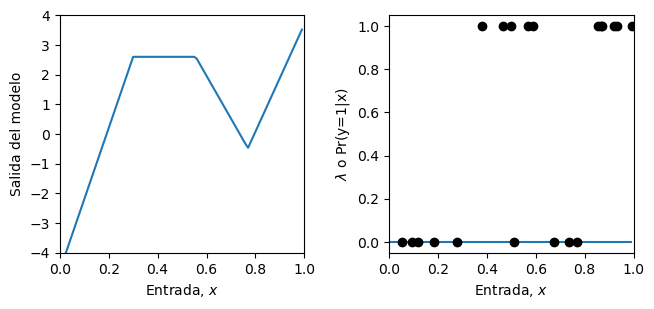

In [6]:
# Crea algunos datos de entrenamiento unidimensionales
x_train = np.array([0.09291784,0.46809093,0.93089486,0.67612654,0.73441752,0.86847339,\
                   0.49873225,0.51083168,0.18343972,0.99380898,0.27840809,0.38028817,\
                   0.12055708,0.56715537,0.92005746,0.77072270,0.85278176,0.05315950,\
                   0.87168699,0.58858043])
y_train = np.array([0,1,1,0,0,1,\
                    1,0,0,1,0,1,\
                    0,1,1,0,1,0, \
                    1,1])

# Obtiene los parámetros del modelo
beta_0, omega_0, beta_1, omega_1 = get_parameters()

# Define un rango de valores de entrada
x_model = np.arange(0,1,0.01)
# Ejecuta el modelo para obtener y graficar sus valores
model_out= shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
lambda_model = sigmoid(model_out)
plot_binary_classification(x_model, model_out, lambda_model, x_train, y_train)


A la izquierda se muestra la salida del modelo y a la derecha, la salida después de aplicar la sigmoide. Ahora está en el rango [0,1] y representa la probabilidad de que y=1. Los puntos negros son los datos de entrenamiento. Calcularemos la likelihood y la likelihood logarítmica negativa.

In [18]:
# Devuelve la probabilidad de la clase observada y según una distribución de Bernoulli
def bernoulli_distribution(y, lambda_param):
    # TODO: escribe la ecuación de la distribución de Bernoulli
    # Reemplaza la línea siguiente
    prob = (lambda_param ** y) * ((1 - lambda_param) ** (1 - y))
    return prob

In [19]:
# Comprueba que se obtiene la respuesta correcta antes de continuar
print("Respuesta correcta = %3.3f, Tu respuesta = %3.3f"%(0.8,bernoulli_distribution(0,0.2)))
print("Respuesta correcta = %3.3f, Tu respuesta = %3.3f"%(0.2,bernoulli_distribution(1,0.2)))

Respuesta correcta = 0.800, Tu respuesta = 0.800
Respuesta correcta = 0.200, Tu respuesta = 0.200


Ahora calcula la likelihood con esta función.

In [20]:
# Devuelve la likelihood de todos los datos según el modelo
def compute_likelihood(y_train, lambda_param):
  # TODO: calcula la likelihood de los datos como el producto de las probabilidades de Bernoulli de cada punto
  # Necesitarás np.prod() y la función bernoulli_distribution usada anteriormente
  # Reemplaza la línea siguiente
  likelihood = np.prod(bernoulli_distribution(y_train, lambda_param))
  return likelihood

In [21]:
# Prueba la función
beta_0, omega_0, beta_1, omega_1 = get_parameters()
# Usa la red neuronal para predecir el parámetro lambda de Bernoulli
model_out = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
lambda_train = sigmoid(model_out)
# Calcula la likelihood
likelihood = compute_likelihood(y_train, lambda_train)
# Comprueba que se obtiene la respuesta correcta antes de continuar
print("Respuesta correcta = %9.9f, Tu respuesta = %9.9f"%(0.000070237,likelihood))

Respuesta correcta = 0.000070237, Tu respuesta = 0.000070237


El resultado es muy pequeño, incluso para este conjunto de datos unidimensional y con un buen ajuste del modelo. Esto ocurre porque es el producto de varias probabilidades que también son pequeñas.
Con conjuntos de datos reales, la likelihood se vuelve tan pequeña que no puede representarse con la aritmética habitual de precisión finita.

Por eso usamos la likelihood logarítmica negativa.

In [22]:
# Devuelve la likelihood logarítmica negativa de los datos según el modelo
def compute_negative_log_likelihood(y_train, lambda_param):
  # TODO: calcula la likelihood logarítmica negativa sin usar la función de likelihood anterior; calcula la suma negativa de los logaritmos de las probabilidades
  # Necesitarás np.sum() y np.log()
  # Reemplaza la línea siguiente
  nll = -np.sum(np.log(bernoulli_distribution(y_train, lambda_param)))
  return nll

In [23]:
# Prueba la función
beta_0, omega_0, beta_1, omega_1 = get_parameters()
# Usa la red neuronal para predecir la media de la distribución gaussiana
model_out = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
# Aplica la función sigmoide
lambda_train = sigmoid(model_out)
# Calcula la likelihood logarítmica negativa
nll = compute_negative_log_likelihood(y_train, lambda_train)
# Comprueba que se obtiene la respuesta correcta antes de continuar
print("Respuesta correcta = %9.9f, Tu respuesta = %9.9f"%(9.563639387,nll))

Respuesta correcta = 9.563639387, Tu respuesta = 9.563639387


Ahora estudiaremos cómo encontrar la solución de máxima likelihood o mínima likelihood logarítmica negativa. Para simplificar, supondremos que todos los parámetros están fijos excepto uno y observaremos cómo cambian ambas medidas al modificar el último parámetro. Comenzaremos con el desplazamiento general de y, beta_1 (antes phi_0).

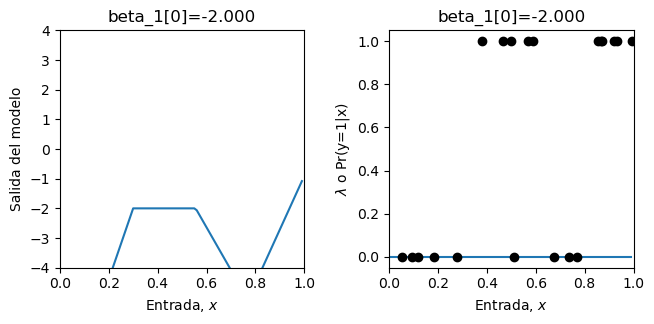

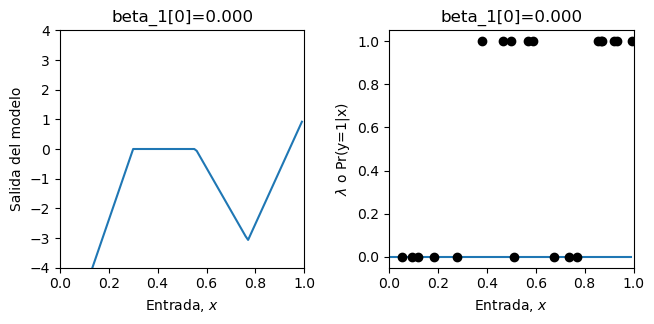

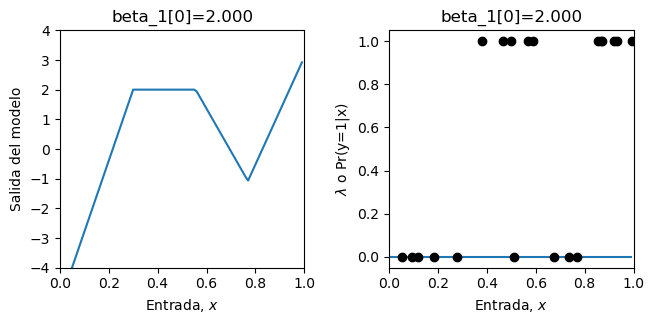

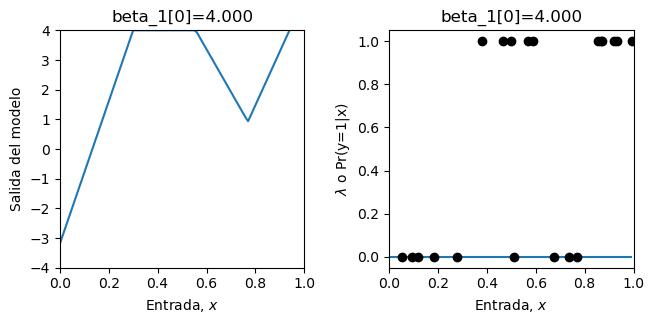

In [13]:
# Define un rango de valores para el parámetro
beta_1_vals = np.arange(-2,6.0,0.1)
# Crea arreglos para almacenar las likelihood y las likelihood logarítmicas negativas
likelihoods = np.zeros_like(beta_1_vals)
nlls = np.zeros_like(beta_1_vals)

# Inicializa los parámetros
beta_0, omega_0, beta_1, omega_1 = get_parameters()
for count in range(len(beta_1_vals)):
  # Asigna el valor del parámetro
  beta_1[0,0] = beta_1_vals[count]
  # Ejecuta la red con los nuevos parámetros
  model_out = shallow_nn(x_train, beta_0, omega_0, beta_1, omega_1)
  lambda_train = sigmoid(model_out)
  # Calcula y almacena los dos valores
  likelihoods[count] = compute_likelihood(y_train,lambda_train)
  nlls[count] = compute_negative_log_likelihood(y_train, lambda_train)
  # Dibuja el modelo cada 20 configuraciones del parámetro
  if count % 20 == 0:
    # Ejecuta el modelo para obtener y graficar sus valores
    model_out = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
    lambda_model = sigmoid(model_out)
    plot_binary_classification(x_model, model_out, lambda_model, x_train, y_train, title="beta_1[0]=%3.3f"%(beta_1[0,0]))


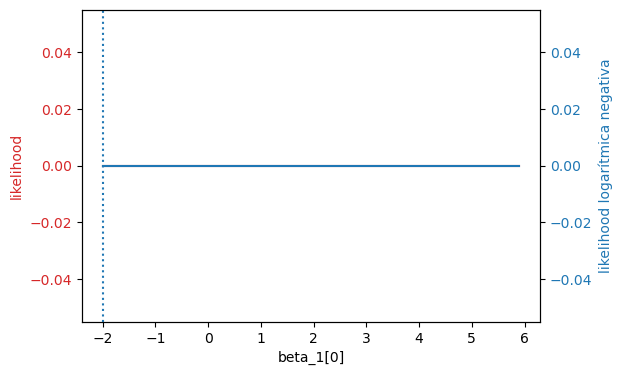

In [14]:
# Grafica la likelihood y la likelihood logarítmica negativa según el valor del desplazamiento beta1
fig, ax = plt.subplots()
fig.tight_layout(pad=5.0)
likelihood_color = 'tab:red'
nll_color = 'tab:blue'


ax.set_xlabel('beta_1[0]')
ax.set_ylabel('likelihood', color = likelihood_color)
ax.plot(beta_1_vals, likelihoods, color = likelihood_color)
ax.tick_params(axis='y', labelcolor=likelihood_color)

ax1 = ax.twinx()
ax1.plot(beta_1_vals, nlls, color = nll_color)
ax1.set_ylabel('likelihood logarítmica negativa', color = nll_color)
ax1.tick_params(axis='y', labelcolor = nll_color)

plt.axvline(x = beta_1_vals[np.argmax(likelihoods)], linestyle='dotted')

plt.show()

Máxima likelihood = 0.000000, en beta_1=-2.000
Mínima likelihood logarítmica negativa = 0.000000, en beta_1=-2.000


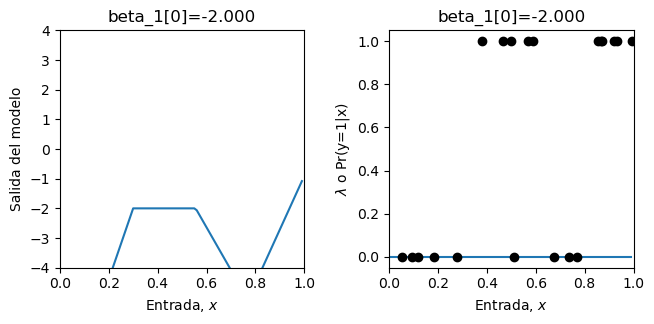

In [15]:
# El máximo de la likelihood debe estar en la misma posición que el mínimo de la likelihood logarítmica negativa
# Compruébalo:
print("Máxima likelihood = %f, en beta_1=%3.3f"%( (likelihoods[np.argmax(likelihoods)],beta_1_vals[np.argmax(likelihoods)])))
print("Mínima likelihood logarítmica negativa = %f, en beta_1=%3.3f"%( (nlls[np.argmin(nlls)],beta_1_vals[np.argmin(nlls)])))

# Grafica el mejor modelo
beta_1[0,0] = beta_1_vals[np.argmin(nlls)]
model_out = shallow_nn(x_model, beta_0, omega_0, beta_1, omega_1)
lambda_model = sigmoid(model_out)
plot_binary_classification(x_model, model_out, lambda_model, x_train, y_train, title="beta_1[0]=%3.3f"%(beta_1[0,0]))


Ambas medidas dan la misma respuesta. Sin embargo, la likelihood es muy pequeña a menos que los parámetros sean casi correctos. Por eso, en la práctica se trabaja con la likelihood logarítmica negativa.<br><br>

Para ajustar el modelo neuronal completo, variaríamos los 10 parámetros de la red en $\boldsymbol\beta_{0},\boldsymbol\Omega_{0},\boldsymbol\beta_{1},\boldsymbol\Omega_{1}$ hasta encontrar la combinación con máxima likelihood o mínima likelihood logarítmica negativa.<br><br>

